# Entrenamiento CNN para Behavioral Cloning

Este notebook prepara la estructura de entrenamiento de una red neuronal convolucional basada en la arquitectura NVIDIA para Behavioral Cloning. La preparacion incluye lectura de anotaciones, asociacion de imagenes con targets, exploracion basica, preprocesamiento, particion entrenamiento/prueba, pipeline `tf.data`, data augmentation seguro para regresion y definicion/compilacion del modelo.

**Importante:** este notebook no ejecuta el entrenamiento automaticamente. El bloque `model.fit` queda comentado para ejecutarse manualmente cuando el dataset este validado.

## 1. Importacion de librerias necesarias

Se cargan librerias estandar, utilidades para lectura de anotaciones y TensorFlow/Keras para el pipeline de datos y el modelo.

In [30]:
!git clone https://github.com/DylanQH/Dataset_equipo10.git

fatal: destination path 'Dataset_equipo10' already exists and is not an empty directory.


In [31]:
#!pip install keras==3.12.1

In [32]:
#!pip install tensorflow==2.20.0

In [33]:
from pathlib import Path
from collections import Counter
import csv
import json
import random

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError(
        "TensorFlow no esta instalado en este entorno. Instala tensorflow antes de ejecutar el pipeline."
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", tf.keras.__version__)
print("TensorFlow:", tf.__version__)

Keras: 3.13.2
TensorFlow: 2.20.0


## 2. Definicion de rutas del proyecto

Las rutas se detectan desde la carpeta actual o desde alguno de sus padres. Se soporta tanto la estructura local `resources/...` como la variante `ProyectoFinal_Dataset/resources/...` indicada en el enunciado.

In [34]:
DATASET_RELATIVE_CANDIDATES = [
    Path("Dataset_equipo10"),
    #Path("ProyectoFinal_Dataset/dataset_equipo10"),
]

def find_dataset_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for relative_path in DATASET_RELATIVE_CANDIDATES:
            candidate = base / relative_path
            if candidate.exists():
                if relative_path.parts[0] == "ProyectoFinal_Dataset":
                    project_root = base / "ProyectoFinal_Dataset"
                else:
                    project_root = base
                return project_root.resolve(), candidate.resolve()
    searched = [str(path) for path in DATASET_RELATIVE_CANDIDATES]
    raise FileNotFoundError(f"No se encontro el dataset. Rutas relativas buscadas: {searched}")

PROJECT_ROOT, DATASET_DIR = find_dataset_dir()
IMAGE_DIR = DATASET_DIR / "JPEGImages"
ANNOTATION_DIR = DATASET_DIR / "Annotations"
TRAINING_ROOT = DATASET_DIR.parent
MODEL_DIR = TRAINING_ROOT / "models"
OUTPUT_DIR = TRAINING_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "behavioral_cloning_nvidia.keras"
HISTORY_PATH = OUTPUT_DIR / "behavioral_cloning_history.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("ANNOTATION_DIR:", ANNOTATION_DIR)
print("MODEL_PATH:", MODEL_PATH)

PROJECT_ROOT: /content
DATASET_DIR: /content/Dataset_equipo10
IMAGE_DIR: /content/Dataset_equipo10/JPEGImages
ANNOTATION_DIR: /content/Dataset_equipo10/Annotations
MODEL_PATH: /content/models/behavioral_cloning_nvidia.keras


## 3. Lectura y procesamiento de las anotaciones

El dataset actual usa archivos `.csv` con las columnas `image_name`, `steering_angle` y `nav_command`. Para Behavioral Cloning se toma `steering_angle` como target numerico continuo y se conserva `nav_command` como metadato auxiliar para exploracion.

In [35]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg"}
IMAGE_COLUMN = "image_name"
TARGET_COLUMN = "steering_angle"
AUXILIARY_COLUMN = "nav_command"
REQUIRED_ANNOTATION_COLUMNS = {IMAGE_COLUMN, TARGET_COLUMN}

def clean_image_name(value):
    return Path(str(value).strip()).name if value not in (None, "") else None

def to_float(value):
    try:
        return float(str(value).strip().replace(",", "."))
    except (TypeError, ValueError):
        return None

def load_annotation_csvs(annotation_dir):
    annotation_files = sorted(
        path for path in annotation_dir.glob("*.csv")
        if path.is_file() and not path.name.startswith(".")
    )
    records = []
    invalid_rows = []
    invalid_files = []

    for csv_path in annotation_files:
        with csv_path.open("r", encoding="utf-8-sig", newline="") as file:
            reader = csv.DictReader(file)
            missing_columns = REQUIRED_ANNOTATION_COLUMNS - set(reader.fieldnames or [])
            if missing_columns:
                invalid_files.append((csv_path, f"faltan columnas: {sorted(missing_columns)}"))
                continue

            for row_number, row in enumerate(reader, start=2):
                image_name = clean_image_name(row.get(IMAGE_COLUMN))
                target = to_float(row.get(TARGET_COLUMN))
                if not image_name or target is None:
                    invalid_rows.append((csv_path.name, row_number, row))
                    continue

                records.append({
                    "image_name": image_name,
                    "target": target,
                    "nav_command": row.get(AUXILIARY_COLUMN),
                    "annotation_file": str(csv_path),
                })

    return records, annotation_files, invalid_rows, invalid_files

annotation_records, annotation_files, invalid_annotation_rows, invalid_annotation_files = load_annotation_csvs(ANNOTATION_DIR)

print("Archivos CSV de anotacion:", len(annotation_files))
print("Registros de anotacion validos:", len(annotation_records))
print("Filas invalidas omitidas:", len(invalid_annotation_rows))
print("Archivos invalidos omitidos:", len(invalid_annotation_files))
if invalid_annotation_files:
    print("Archivos invalidos:")
    for path, reason in invalid_annotation_files:
        print("-", path.name, reason)

Archivos CSV de anotacion: 19
Registros de anotacion validos: 17863
Filas invalidas omitidas: 0
Archivos invalidos omitidos: 0


## 4. Carga de imagenes y asociacion con su target

Se listan las imagenes disponibles y se asocian con las anotaciones por nombre de archivo. Los registros sin imagen correspondiente o duplicados se reportan para revision.

In [36]:
def list_image_files(image_dir):
    return sorted(
        path for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def build_dataset_records(image_dir, annotation_records):
    image_files = list_image_files(image_dir)
    images_by_name = {path.name.lower(): path.resolve() for path in image_files}

    dataset_records = []
    missing_images = []
    duplicate_annotations = []
    used_image_names = set()

    for record in annotation_records:
        image_name = record["image_name"]
        image_path = images_by_name.get(image_name.lower())
        if image_path is None:
            missing_images.append(record)
            continue
        if image_name.lower() in used_image_names:
            duplicate_annotations.append(record)
            continue

        used_image_names.add(image_name.lower())
        dataset_records.append({
            **record,
            "image_path": image_path,
            "image_name": image_path.name,
        })

    images_without_annotation = [
        path for path in image_files
        if path.name.lower() not in used_image_names
    ]
    return dataset_records, image_files, missing_images, duplicate_annotations, images_without_annotation

dataset_records, image_files, missing_images, duplicate_annotations, images_without_annotation = build_dataset_records(
    IMAGE_DIR,
    annotation_records,
)

print("Imagenes encontradas:", len(image_files))
print("Registros finales imagen-target:", len(dataset_records))
print("Anotaciones sin imagen:", len(missing_images))
print("Anotaciones duplicadas omitidas:", len(duplicate_annotations))
print("Imagenes sin anotacion:", len(images_without_annotation))

Imagenes encontradas: 17595
Registros finales imagen-target: 17595
Anotaciones sin imagen: 268
Anotaciones duplicadas omitidas: 0
Imagenes sin anotacion: 0


## 5. Exploracion basica del dataset

Se muestran conteos principales, ejemplos de registros y validaciones de archivos faltantes. Si no hay datos descargados o no hay anotaciones validas, esta celda lo reportara antes de avanzar al entrenamiento.

In [37]:
def preview_records(records, n=5):
    preview = [
        {
            "image_name": record["image_name"],
            "target": record["target"],
            "nav_command": record.get("nav_command"),
            "annotation_file": Path(record["annotation_file"]).name,
        }
        for record in records[:n]
    ]
    if pd is not None:
        display(pd.DataFrame(preview))
    else:
        for item in preview:
            print(item)

print("Total de imagenes en carpeta:", len(image_files))
print("Total de registros usables:", len(dataset_records))
print("Targets validos:", sum(np.isfinite(record["target"]) for record in dataset_records))

if dataset_records:
    targets = np.array([record["target"] for record in dataset_records], dtype=np.float32)
    print("Target minimo:", float(np.min(targets)))
    print("Target maximo:", float(np.max(targets)))
    print("Target promedio:", float(np.mean(targets)))
    print("Desviacion estandar target:", float(np.std(targets)))
    nav_commands = [record.get("nav_command") for record in dataset_records if record.get("nav_command") not in (None, "")]
    if nav_commands:
        print("Distribucion nav_command:", dict(sorted(Counter(nav_commands).items())))
    preview_records(dataset_records, n=5)
else:
    print("No hay registros usables. Verifica que existan imagenes y anotaciones validas.")

if missing_images[:5]:
    print("Primeras anotaciones sin imagen:", missing_images[:5])
if images_without_annotation[:5]:
    print("Primeras imagenes sin anotacion:", [path.name for path in images_without_annotation[:5]])

Total de imagenes en carpeta: 17595
Total de registros usables: 17595
Targets validos: 17595
Target minimo: -0.5
Target maximo: 0.5
Target promedio: -0.002475135028362274
Desviacion estandar target: 0.1297413557767868
Distribucion nav_command: {'0': 6931, '1': 5123, '2': 5541}


,image_name,target,nav_command,annotation_file
0,yutsil_blue_25_06_2026_13_57_frame_1.jpeg,0.0,1,yutsil_blue_25_06_2026_13_57.csv
1,yutsil_blue_25_06_2026_13_57_frame_2.jpeg,0.0,1,yutsil_blue_25_06_2026_13_57.csv
2,yutsil_blue_25_06_2026_13_57_frame_3.jpeg,0.0,1,yutsil_blue_25_06_2026_13_57.csv
3,yutsil_blue_25_06_2026_13_57_frame_4.jpeg,0.0,1,yutsil_blue_25_06_2026_13_57.csv
4,yutsil_blue_25_06_2026_13_57_frame_5.jpeg,0.0,1,yutsil_blue_25_06_2026_13_57.csv


Primeras anotaciones sin imagen: [{'image_name': 'yutsil_blue_28_06_2026_00_55_frame_1.jpeg', 'target': 0.0, 'nav_command': '1', 'annotation_file': '/content/Dataset_equipo10/Annotations/yutsil_blue_28_06_2026_00_55.csv'}, {'image_name': 'yutsil_blue_28_06_2026_00_55_frame_2.jpeg', 'target': 0.0, 'nav_command': '1', 'annotation_file': '/content/Dataset_equipo10/Annotations/yutsil_blue_28_06_2026_00_55.csv'}, {'image_name': 'yutsil_blue_28_06_2026_00_55_frame_3.jpeg', 'target': 0.0, 'nav_command': '1', 'annotation_file': '/content/Dataset_equipo10/Annotations/yutsil_blue_28_06_2026_00_55.csv'}, {'image_name': 'yutsil_blue_28_06_2026_00_55_frame_4.jpeg', 'target': 0.0, 'nav_command': '1', 'annotation_file': '/content/Dataset_equipo10/Annotations/yutsil_blue_28_06_2026_00_55.csv'}, {'image_name': 'yutsil_blue_28_06_2026_00_55_frame_5.jpeg', 'target': 0.0, 'nav_command': '1', 'annotation_file': '/content/Dataset_equipo10/Annotations/yutsil_blue_28_06_2026_00_55.csv'}]


## 5.1 Histograma de la variable objetivo

Antes de separar el dataset, se visualiza la distribucion de steering_angle. Esto ayuda a detectar desbalance, concentracion excesiva cerca de cero o valores extremos que puedan afectar el entrenamiento.

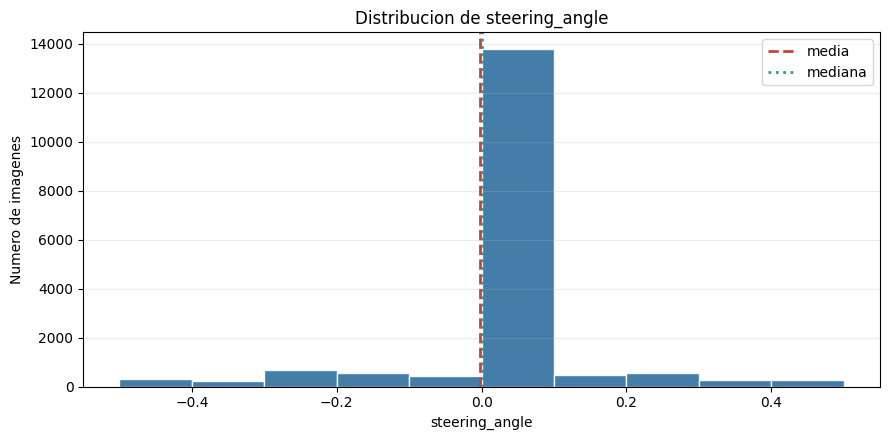

In [38]:
def plot_target_histogram(records, bins=50):
    if not records:
        print("No hay registros disponibles para graficar el histograma del target.")
        return

    targets = np.array([record["target"] for record in records], dtype=np.float32)
    plt.figure(figsize=(9, 4.5))
    plt.hist(targets, bins=bins, color="#2f6f9f", edgecolor="white", alpha=0.9)
    plt.axvline(float(np.mean(targets)), color="#c44536", linestyle="--", linewidth=2, label="media")
    plt.axvline(float(np.median(targets)), color="#2a9d8f", linestyle=":", linewidth=2, label="mediana")
    plt.title("Distribucion de steering_angle")
    plt.xlabel("steering_angle")
    plt.ylabel("Numero de imagenes")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()

plot_target_histogram(dataset_records, bins=10)

## 5.2 Submuestreo de angulos cero

La distribucion de steering_angle suele concentrarse en cero porque el vehiculo pasa mucho tiempo avanzando recto. Para reducir ese sesgo antes del train/test split, se conservan todos los registros con angulo distinto de cero y se toma una muestra reproducible de 2000 registros con angulo cero.

Registros originales: 17595
Angulos distintos de cero conservados: 4312
Angulos cero originales: 13283
Angulos cero seleccionados: 4312
Registros despues del submuestreo: 8624


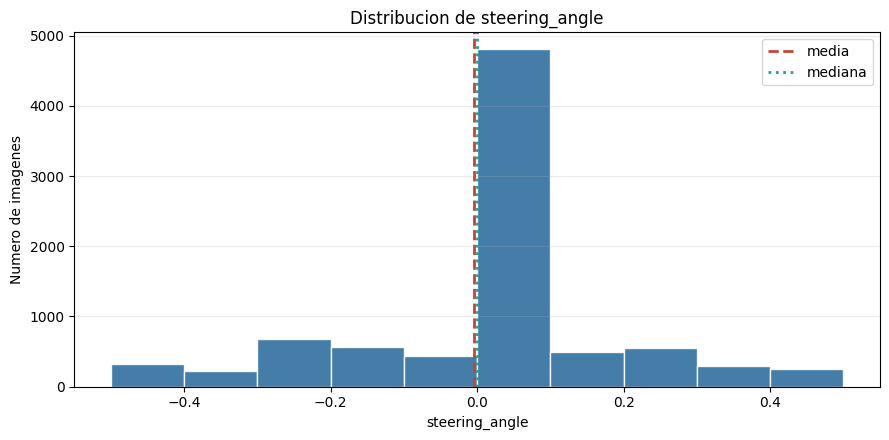

In [39]:
MAX_ZERO_TARGET_SAMPLES = 4312
ZERO_TARGET_TOLERANCE = 1e-6

def downsample_zero_targets(records, max_zero_samples=MAX_ZERO_TARGET_SAMPLES, seed=SEED):
    zero_records = [record for record in records if abs(record["target"]) <= ZERO_TARGET_TOLERANCE]
    non_zero_records = [record for record in records if abs(record["target"]) > ZERO_TARGET_TOLERANCE]

    rng = np.random.default_rng(seed)
    if len(zero_records) > max_zero_samples:
        selected_zero_indices = rng.choice(len(zero_records), size=max_zero_samples, replace=False)
        selected_zero_records = [zero_records[index] for index in selected_zero_indices]
    else:
        selected_zero_records = zero_records

    balanced_records = non_zero_records + selected_zero_records
    balanced_indices = np.arange(len(balanced_records))
    rng.shuffle(balanced_indices)
    balanced_records = [balanced_records[index] for index in balanced_indices]

    print("Registros originales:", len(records))
    print("Angulos distintos de cero conservados:", len(non_zero_records))
    print("Angulos cero originales:", len(zero_records))
    print("Angulos cero seleccionados:", len(selected_zero_records))
    print("Registros despues del submuestreo:", len(balanced_records))
    return balanced_records

balanced_dataset_records = downsample_zero_targets(dataset_records)
plot_target_histogram(balanced_dataset_records, bins=10)

## 6. Preprocesamiento de imagenes

TensorFlow decodifica JPEG en formato RGB. Las imagenes se redimensionan al tamano usado por la arquitectura NVIDIA (`66 x 200`) y se normalizan a valores `float32` en el rango `[0, 1]`.

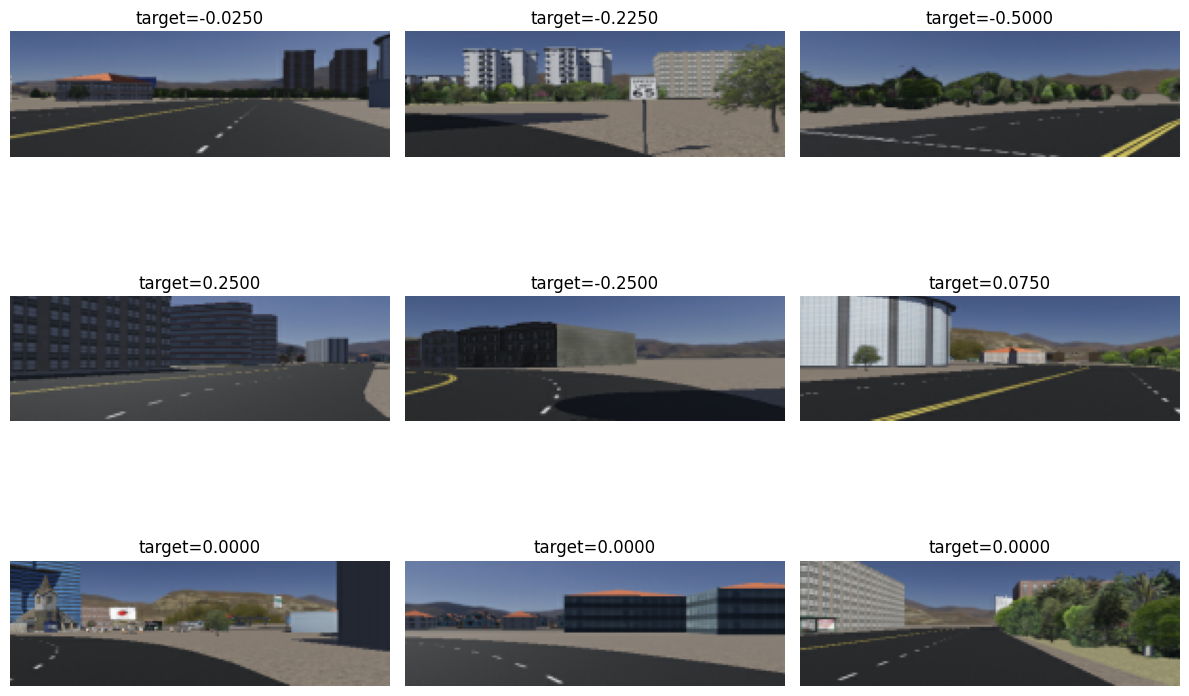

In [40]:
IMG_HEIGHT = 66
IMG_WIDTH = 200
IMG_CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, target):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_bytes, channels=IMG_CHANNELS)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH], method="area")
    return image, target

def show_preprocessed_examples(records, n=9):
    if not records:
        print("No hay ejemplos para visualizar.")
        return
    sample = records[: min(n, len(records))]
    cols = min(3, len(sample))
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    for index, record in enumerate(sample, start=1):
        image, target = load_and_preprocess_image(str(record["image_path"]), np.array([record["target"]], dtype=np.float32))
        plt.subplot(rows, cols, index)
        plt.imshow(image.numpy())
        plt.title(f"target={float(target[0]):.4f}")
        plt.axis("off")
    plt.tight_layout()

show_preprocessed_examples(balanced_dataset_records, n=9)

## 7. Separacion del dataset en entrenamiento y prueba

Se usa 80% para entrenamiento y 20% para prueba con semilla fija para reproducibilidad.

In [41]:
TEST_SIZE = 0.20

def train_test_split_records(records, test_size=TEST_SIZE, seed=SEED):
    if len(records) < 2:
        raise ValueError("Se necesitan al menos 2 registros validos para separar entrenamiento y prueba.")
    rng = np.random.default_rng(seed)
    indices = np.arange(len(records))
    rng.shuffle(indices)
    test_count = max(1, int(round(len(records) * test_size)))
    test_indices = set(indices[:test_count])
    train_records = [record for idx, record in enumerate(records) if idx not in test_indices]
    test_records = [record for idx, record in enumerate(records) if idx in test_indices]
    return train_records, test_records

train_records, test_records = train_test_split_records(balanced_dataset_records)

print("Registros de entrenamiento:", len(train_records))
print("Registros de prueba:", len(test_records))
print("Proporcion prueba:", len(test_records) / len(balanced_dataset_records))

Registros de entrenamiento: 6899
Registros de prueba: 1725
Proporcion prueba: 0.20002319109461966


## 8. Data augmentation seguro para Behavioral Cloning

Se aplican aumentos que no requieren cambiar el target: zoom centrado, desplazamiento vertical leve, brillo y contraste. No se aplica rotacion ni volteo horizontal porque podrian cambiar la interpretacion del target. Si el target representa angulo de direccion, un volteo horizontal requeriria invertir el signo del target.

In [42]:
geometric_augmenter = keras.Sequential(
    [
        layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08), fill_mode="reflect", seed=SEED),
        layers.RandomTranslation(height_factor=0.04, width_factor=0.0, fill_mode="reflect", seed=SEED),
    ],
    name="safe_geometric_augmentation",
)

HORIZONTAL_FLIP_PROBABILITY = 0.50

def random_horizontal_flip_with_target(image, target, probability=HORIZONTAL_FLIP_PROBABILITY):
    should_flip = tf.random.uniform((), minval=0.0, maxval=1.0, seed=SEED) < probability
    image = tf.cond(
        should_flip,
        lambda: tf.image.flip_left_right(image),
        lambda: image,
    )
    target = tf.cond(
        should_flip,
        lambda: -target,
        lambda: target,
    )
    return image, target

def augment_image(image, target):
    image, target = random_horizontal_flip_with_target(image, target)
    image = tf.expand_dims(image, axis=0)
    image = geometric_augmenter(image, training=True)
    image = tf.squeeze(image, axis=0)
    image = tf.image.random_brightness(image, max_delta=0.08, seed=SEED)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15, seed=SEED)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15, seed=SEED)
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.01, seed=SEED)
    image = image + noise
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, target

# 8.1 Visualizacion de data augmentation

Se aplican aumentos que no requieren cambiar el target: zoom centrado, desplazamiento vertical leve, brillo, contraste, saturacion y ruido gaussiano leve. No se aplica rotacion, volteo horizontal ni desplazamiento horizontal porque podrian cambiar la interpretacion del target. Si el target representa angulo de direccion, un volteo horizontal requeriria invertir el signo del target.

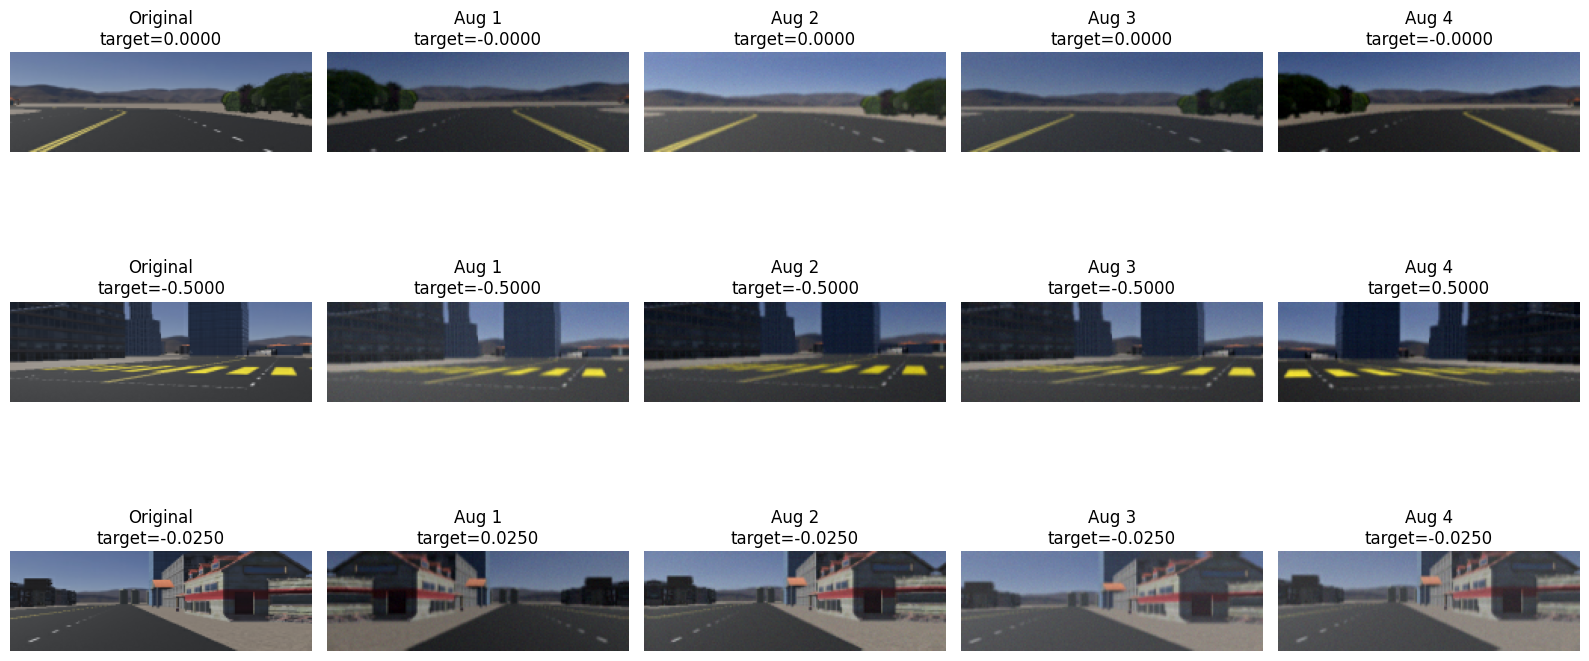

In [43]:
def show_augmented_examples(records, n_images=3, n_augmented=4, randomize=True):
    if not records:
        print("No hay registros disponibles para visualizar augmentation.")
        return

    n_images = min(n_images, len(records))
    if randomize:
        rng = np.random.default_rng()
        sample_indices = rng.choice(len(records), size=n_images, replace=False)
        sample_records = [records[index] for index in sample_indices]
    else:
        sample_records = records[:n_images]

    cols = n_augmented + 1
    fig, axes = plt.subplots(
        len(sample_records),
        cols,
        figsize=(3.2 * cols, 2.8 * len(sample_records)),
        squeeze=False,
    )

    for row_idx, record in enumerate(sample_records):
        image, target = load_and_preprocess_image(
            str(record["image_path"]),
            tf.constant([record["target"]], dtype=tf.float32),
        )

        axes[row_idx, 0].imshow(image.numpy())
        axes[row_idx, 0].set_title(f"Original\ntarget={float(target[0]):.4f}")
        axes[row_idx, 0].axis("off")

        for col_idx in range(1, cols):
            augmented_image, augmented_target = augment_image(image, target)
            axes[row_idx, col_idx].imshow(augmented_image.numpy())
            axes[row_idx, col_idx].set_title(f"Aug {col_idx}\ntarget={float(augmented_target[0]):.4f}")
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()


show_augmented_examples(train_records, n_images=3, n_augmented=4)

## 9. Pipeline de datos con tf.data

El pipeline carga rutas y targets, preprocesa imagenes, aplica augmentation solo al conjunto de entrenamiento, agrupa en batches y usa prefetch para mejorar rendimiento.

In [44]:
def records_to_arrays(records):
    image_paths = np.array([str(record["image_path"]) for record in records], dtype=str)
    targets = np.array([record["target"] for record in records], dtype=np.float32).reshape(-1, 1)
    return image_paths, targets

def make_dataset(records, training=False, batch_size=BATCH_SIZE):
    image_paths, targets = records_to_arrays(records)
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    if training:
        dataset = dataset.shuffle(buffer_size=len(records), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.map(augment_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_records, training=True)
test_ds = make_dataset(test_records, training=False)

for images_batch, targets_batch in train_ds.take(1):
    print("Batch imagenes:", images_batch.shape)
    print("Batch targets:", targets_batch.shape)
    print("Rango pixeles:", float(tf.reduce_min(images_batch)), float(tf.reduce_max(images_batch)))

Batch imagenes: (32, 66, 200, 3)
Batch targets: (32, 1)
Rango pixeles: 0.0 1.0


## 10. Construccion del modelo CNN tipo NVIDIA

La arquitectura sigue el archivo `Modelo_nvidia_ejemplo.py`: convoluciones con `ELU`, reduccion progresiva de resolucion y capas densas para producir una salida continua de regresion. Se usa la API actual de Keras y entrada `(66, 200, 3)`.

In [45]:
def build_nvidia_behavioral_cloning_model(input_shape=INPUT_SHAPE):
    inputs = keras.Input(shape=input_shape, name="camera_image")
    x = inputs
    x = layers.Conv2D(24, kernel_size=(5, 5), strides=(2, 2), activation="relu", name="conv_24_5x5_s2")(x)
    x = layers.Conv2D(36, kernel_size=(5, 5), strides=(2, 2), activation="relu", name="conv_36_5x5_s2")(x)
    x = layers.Conv2D(48, kernel_size=(5, 5), strides=(2, 2), activation="relu", name="conv_48_5x5_s2")(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_64_3x3_1")(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_64_3x3_2")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(100, activation="relu", name="dense_100")(x)
    x = layers.Dense(50, activation="relu", name="dense_50")(x)
    x = layers.Dense(10, activation="relu", name="dense_10")(x)
    outputs = layers.Dense(1, activation="linear", name="target_output")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="nvidia_behavioral_cloning")

model = build_nvidia_behavioral_cloning_model(INPUT_SHAPE)
model.summary()

Model: "nvidia_behavioral_cloning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camera_image (InputLayer)       │ (None, 66, 200, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_24_5x5_s2 (Conv2D)         │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_36_5x5_s2 (Conv2D)         │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_48_5x5_s2 (Conv2D)         │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64_3x3_1 (Conv2D)          │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64_3x3_2 (Conv2D)          │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_output (Dense)           │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Compilacion del modelo

La tarea se formula como regresion. La perdida y metrica principal son MSE. Se agrega MAE como metrica auxiliar interpretable.

In [ ]:
LEARNING_RATE = 1e-4

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=[
        keras.metrics.MeanSquaredError(name="mse"),
        keras.metrics.MeanAbsoluteError(name="mae"),
    ],
)

print("Modelo compilado con loss=mse y metrica principal=mse.")

Modelo compilado con loss=mse y metrica principal=mse.


## 12. Estructura de entrenamiento (no ejecutar automaticamente)

El siguiente bloque queda comentado intencionalmente. Cuando el dataset este validado, descomenta estas lineas para entrenar manualmente.

In [ ]:
EPOCHS = 8

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_mse",
        mode="min",
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_mse",
        mode="min",
        patience=5,
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - loss: 0.0290 - mae: 0.1160 - mse: 0.0290 - val_loss: 0.0284 - val_mae: 0.1186 - val_mse: 0.0284
Epoch 2/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 34s 155ms/step - loss: 0.0287 - mae: 0.1157 - mse: 0.0287 - val_loss: 0.0288 - val_mae: 0.1223 - val_mse: 0.0288
Epoch 3/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - loss: 0.0284 - mae: 0.1154 - mse: 0.0284 - val_loss: 0.0288 - val_mae: 0.1179 - val_mse: 0.0288
Epoch 4/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 154ms/step - loss: 0.0282 - mae: 0.1152 - mse: 0.0282 - val_loss: 0.0278 - val_mae: 0.1153 - val_mse: 0.0278
Epoch 5/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - loss: 0.0281 - mae: 0.1156 - mse: 0.0281 - val_loss: 0.0274 - val_mae: 0.1154 - val_mse: 0.0274
Epoch 6/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - loss: 0.0277 - mae: 0.1144 - mse: 0.0277 - val_loss: 0.0272 - val_mae: 0.1174 - val_mse: 0.0272
Epoch 7/8
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - loss: 0.0278 - mae: 0.1150 - mse

## 12.1 Graficas de metricas de entrenamiento y validacion

Despues de ejecutar model.fit, el objeto history contiene las metricas por epoca. Esta funcion grafica entrenamiento contra validacion para loss, mse y mae cuando esas metricas esten disponibles.

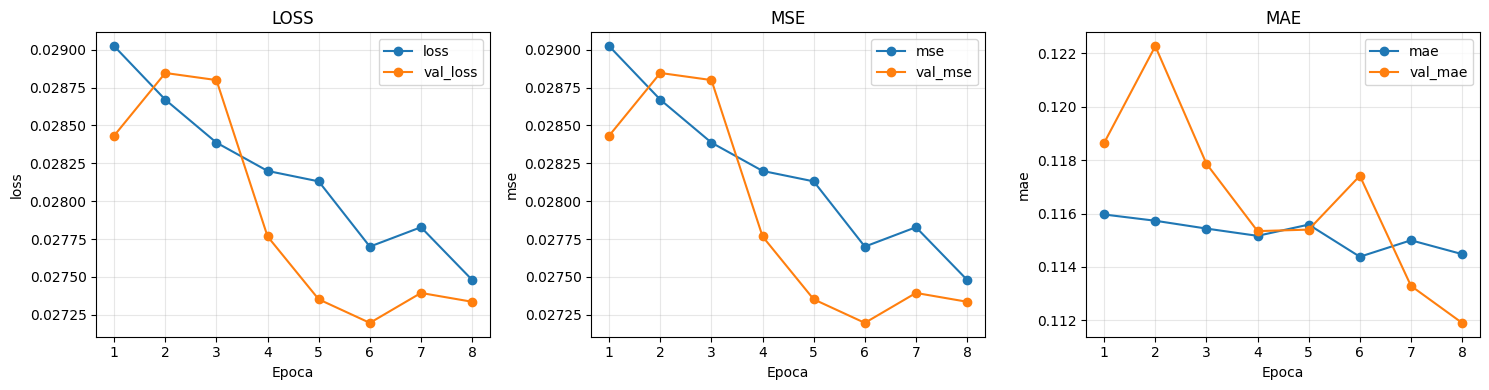

In [ ]:
def plot_training_history(history):
    history_data = history.history if hasattr(history, "history") else history
    metric_pairs = [
        ("loss", "val_loss"),
        ("mse", "val_mse"),
        ("mae", "val_mae"),
    ]
    available_pairs = [
        (train_metric, val_metric)
        for train_metric, val_metric in metric_pairs
        if train_metric in history_data and val_metric in history_data
    ]

    if not available_pairs:
        print("No hay metricas de validacion disponibles para graficar.")
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(5 * len(available_pairs), 4))
    if len(available_pairs) == 1:
        axes = [axes]

    for axis, (train_metric, val_metric) in zip(axes, available_pairs):
        epochs = range(1, len(history_data[train_metric]) + 1)
        axis.plot(epochs, history_data[train_metric], marker="o", label=train_metric)
        axis.plot(epochs, history_data[val_metric], marker="o", label=val_metric)
        axis.set_title(train_metric.upper())
        axis.set_xlabel("Epoca")
        axis.set_ylabel(train_metric)
        axis.grid(True, alpha=0.3)
        axis.legend()

    plt.tight_layout()

plot_training_history(history)

## 13. Guardado posterior del modelo e historial

Estas lineas tambien quedan comentadas. Se deben ejecutar despues de entrenar el modelo.

In [ ]:
#Guardar el modelo entrenado en formato Keras.
model.save('/content/models/behavioral_cloning_nvidia_vcf.keras')
print("Modelo guardado en:", MODEL_PATH)
#Guardar historial si existe la variable history despues de ejecutar model.fit.
history_data = {key: [float(value) for value in values] for key, values in history.history.items()}
with HISTORY_PATH.open("w", encoding="utf-8") as file:
    json.dump(history_data, file, indent=2)
print("Historial guardado en:", HISTORY_PATH)

Modelo guardado en: /content/models/behavioral_cloning_nvidia.keras
Historial guardado en: /content/outputs/behavioral_cloning_history.json
